# Retail Sales Data Analysis

## 1. Project Overview

This project analyzes retail sales data using Customers, Products, Sales, and Stores datasets.

Examine sales performance, customer behavior, product performance, and store performance.

**Tools:** Python, pandas, NumPy, Matplotlib, Seaborn

| Table | Grain | Rows |
|---|---|---|
| Customers | one row per customer | 15,266 |
| Products | one row per product | 2,517 |
| Sales | one row per order line item | 62,884 |
| Stores | one row per store (key 0 = online) | 67 |


## 2. Business Problem

Identify factors associated with sales and profit performance.

Determine high- and low-performing products, categories, and brands.

Understand customer purchasing patterns and behavior.

Identify sales trends, patterns, and potential problem areas.

Evaluate product,customer,sales and store performance to identify areas for business improvement.

## 3. Objectives

- Analyze overall sales performance.
- Identify high-performing and low-performing products.
- Compare store performance.
- Understand customer purchasing behavior.
- Analyze sales trends over time.
- Identify important patterns and potential business problems.
- Create visualizations to communicate findings.
- Generate data-driven insights and recommendations.

## 4.Import Libraries & Load Dataset

In [791]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import calendar


usd_m = mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')

import seaborn as sns
from pathlib import Path

CHART_DIR = Path("../outputs/charts")
CHART_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="white", palette="Dark2", font_scale=1.2)
def save_fig(name):
    plt.tight_layout()
    plt.savefig(CHART_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


In [792]:
encoding_list = [
    'ascii', 'big5', 'big5hkscs', 'cp037', 'cp273', 'cp424', 'cp437', 'cp500', 
    'cp720', 'cp737', 'cp775', 'cp850', 'cp852', 'cp855', 'cp856', 'cp857', 
    'cp858', 'cp860', 'cp861', 'cp862', 'cp863', 'cp864', 'cp865', 'cp866', 
    'cp869', 'cp874', 'cp875', 'cp932', 'cp949', 'cp950', 'cp1006', 'cp1026', 
    'cp1125', 'cp1140', 'cp1250', 'cp1251', 'cp1252', 'cp1253', 'cp1254', 
    'cp1255', 'cp1256', 'cp1257', 'cp1258', 'euc_jp', 'euc_jis_2004', 
    'euc_jisx0213', 'euc_kr', 'gb2312', 'gbk', 'gb18030', 'hz', 'iso2022_jp', 
    'iso2022_jp_1', 'iso2022_jp_2', 'iso2022_jp_2004', 'iso2022_jp_3', 
    'iso2022_jp_ext', 'iso2022_kr', 'latin_1', 'iso8859_2', 'iso8859_3', 
    'iso8859_4', 'iso8859_5', 'iso8859_6', 'iso8859_7', 'iso8859_8', 
    'iso8859_9', 'iso8859_10', 'iso8859_11', 'iso8859_13', 'iso8859_14', 
    'iso8859_15', 'iso8859_16', 'johab', 'koi8_r', 'koi8_t', 'koi8_u', 
    'kz1048', 'mac_cyrillic', 'mac_greek', 'mac_iceland', 'mac_latin2', 
    'mac_roman', 'mac_turkish', 'ptcp154', 'shift_jis', 'shift_jis_2004', 
    'shift_jisx0213', 'utf_32', 'utf_32_be', 'utf_32_le', 'utf_16', 
    'utf_16_be', 'utf_16_le', 'utf_7', 'utf_8', 'utf_8_sig'
]
for encoding in encoding_list:
    worked =True
    try:
        customers = pd.read_csv("../data/raw/Customers.csv",encoding=encoding)
    except:
        worked = False
print(f"Encoding: {encoding}, Worked: {worked}")

Encoding: utf_8_sig, Worked: False


In [793]:
products=pd.read_csv("../data/raw/Products.csv")
sales = pd.read_csv("../data/raw/Sales.csv")
stores = pd.read_csv("../data/raw/Stores.csv")

In [794]:
customers.head()

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,11/19/1965


In [795]:
products.head()

,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,$6.62,$12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,$6.62,$12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,$7.40,$14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,$11.00,$21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,$11.00,$21.57,101,MP4&MP3,1,Audio


In [796]:
sales.head()

,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code
0,366000,1,1/1/2016,NaN,265598,10,1304,1,CAD
1,366001,1,1/1/2016,1/13/2016,1269051,0,1048,2,USD
2,366001,2,1/1/2016,1/13/2016,1269051,0,2007,1,USD
3,366002,1,1/1/2016,1/12/2016,266019,0,1106,7,CAD
4,366002,2,1/1/2016,1/12/2016,266019,0,373,1,CAD


In [797]:
stores.head()

,StoreKey,Country,State,Square Meters,Open Date
0,1,Australia,Australian Capital Territory,595.0,1/1/2008
1,2,Australia,Northern Territory,665.0,1/12/2008
2,3,Australia,South Australia,2000.0,1/7/2012
3,4,Australia,Tasmania,2000.0,1/1/2010
4,5,Australia,Victoria,2000.0,12/9/2015


## 5.Understand the Dataset

### customers

In [798]:
customers.shape

(15266, 10)

In [799]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CustomerKey  15266 non-null  int64 
 1   Gender       15266 non-null  object
 2   Name         15266 non-null  object
 3   City         15266 non-null  object
 4   State Code   15256 non-null  object
 5   State        15266 non-null  object
 6   Zip Code     15266 non-null  object
 7   Country      15266 non-null  object
 8   Continent    15266 non-null  object
 9   Birthday     15266 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.2+ MB


In [800]:
customers.describe()

,CustomerKey
count,1.526600e+04
mean,1.060508e+06
std,6.127097e+05
min,3.010000e+02
25%,5.140335e+05
50%,1.079244e+06
75%,1.593980e+06
max,2.099937e+06


In [801]:
customers.columns

Index(['CustomerKey', 'Gender', 'Name', 'City', 'State Code', 'State',
       'Zip Code', 'Country', 'Continent', 'Birthday'],
      dtype='object')

### products

In [802]:
products.shape

(2517, 10)

In [803]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ProductKey      2517 non-null   int64 
 1   Product Name    2517 non-null   object
 2   Brand           2517 non-null   object
 3   Color           2517 non-null   object
 4   Unit Cost USD   2517 non-null   object
 5   Unit Price USD  2517 non-null   object
 6   SubcategoryKey  2517 non-null   int64 
 7   Subcategory     2517 non-null   object
 8   CategoryKey     2517 non-null   int64 
 9   Category        2517 non-null   object
dtypes: int64(3), object(7)
memory usage: 196.8+ KB


In [804]:
products.describe()

,ProductKey,SubcategoryKey,CategoryKey
count,2517.000000,2517.000000,2517.000000
mean,1259.000000,491.810091,4.878824
std,726.739637,229.887134,2.299170
min,1.000000,101.000000,1.000000
25%,630.000000,305.000000,3.000000
50%,1259.000000,406.000000,4.000000
75%,1888.000000,801.000000,8.000000
max,2517.000000,808.000000,8.000000


In [805]:
products.columns

Index(['ProductKey', 'Product Name', 'Brand', 'Color', 'Unit Cost USD',
       'Unit Price USD', 'SubcategoryKey', 'Subcategory', 'CategoryKey',
       'Category'],
      dtype='object')

### sales

In [806]:
sales.shape

(62884, 9)

In [807]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order Number   62884 non-null  int64 
 1   Line Item      62884 non-null  int64 
 2   Order Date     62884 non-null  object
 3   Delivery Date  13165 non-null  object
 4   CustomerKey    62884 non-null  int64 
 5   StoreKey       62884 non-null  int64 
 6   ProductKey     62884 non-null  int64 
 7   Quantity       62884 non-null  int64 
 8   Currency Code  62884 non-null  object
dtypes: int64(6), object(3)
memory usage: 4.3+ MB


In [808]:
sales.describe()

,Order Number,Line Item,CustomerKey,StoreKey,ProductKey,Quantity
count,6.288400e+04,62884.000000,6.288400e+04,62884.000000,62884.000000,62884.000000
mean,1.430905e+06,2.164207,1.180797e+06,31.802144,1125.859344,3.144790
std,4.532963e+05,1.365170,5.859634e+05,22.978188,709.244010,2.256371
min,3.660000e+05,1.000000,3.010000e+02,0.000000,1.000000,1.000000
25%,1.121017e+06,1.000000,6.808580e+05,8.000000,437.000000,1.000000
50%,1.498016e+06,2.000000,1.261200e+06,37.000000,1358.000000,2.000000
75%,1.788010e+06,3.000000,1.686496e+06,53.000000,1650.000000,4.000000
max,2.243032e+06,7.000000,2.099937e+06,66.000000,2517.000000,10.000000


In [809]:
sales.columns

Index(['Order Number', 'Line Item', 'Order Date', 'Delivery Date',
       'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code'],
      dtype='object')

### stores

In [810]:
stores.shape

(67, 5)

In [811]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StoreKey       67 non-null     int64  
 1   Country        67 non-null     object 
 2   State          67 non-null     object 
 3   Square Meters  66 non-null     float64
 4   Open Date      67 non-null     object 
dtypes: float64(1), int64(1), object(3)
memory usage: 2.7+ KB


In [812]:
stores.describe()

,StoreKey,Square Meters
count,67.000000,66.000000
mean,33.000000,1402.196970
std,19.485037,576.404058
min,0.000000,245.000000
25%,16.500000,1108.750000
50%,33.000000,1347.500000
75%,49.500000,2000.000000
max,66.000000,2105.000000


In [813]:
stores.columns

Index(['StoreKey', 'Country', 'State', 'Square Meters', 'Open Date'], dtype='object')

## 6.Data Cleaning

### customers

In [814]:
customers.isnull().sum()


CustomerKey     0
Gender          0
Name            0
City            0
State Code     10
State           0
Zip Code        0
Country         0
Continent       0
Birthday        0
dtype: int64

In [815]:
customers.dropna(inplace=True)

In [816]:
customers.duplicated().sum()

0

In [817]:
customers['Birthday']=pd.to_datetime(customers['Birthday'])

### products

In [818]:
products.isnull().sum()

ProductKey        0
Product Name      0
Brand             0
Color             0
Unit Cost USD     0
Unit Price USD    0
SubcategoryKey    0
Subcategory       0
CategoryKey       0
Category          0
dtype: int64

In [819]:
products.duplicated().sum()

0

In [820]:
products["Unit Price USD"] = (products["Unit Price USD"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

In [821]:
products["Unit Cost USD"] = (products["Unit Cost USD"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

### sales

In [822]:
sales.isnull().sum()

Order Number         0
Line Item            0
Order Date           0
Delivery Date    49719
CustomerKey          0
StoreKey             0
ProductKey           0
Quantity             0
Currency Code        0
dtype: int64

###### Delivery Date has many missing values. These are retained because a missing delivery date does not make the sales transaction invalid,missing delivery date =offline delivery

In [823]:
sales.duplicated().sum()

0

In [824]:
sales['Order Date']=pd.to_datetime(sales['Order Date'])
sales['Delivery Date']=pd.to_datetime(sales['Delivery Date'])

### stores

In [825]:
stores.isnull().sum()

StoreKey         0
Country          0
State            0
Square Meters    1
Open Date        0
dtype: int64

In [826]:
stores['Square Meters'].fillna(stores['Square Meters'].mean(), inplace=True)


In [827]:
stores.isnull().sum()

StoreKey         0
Country          0
State            0
Square Meters    0
Open Date        0
dtype: int64

In [828]:
stores.duplicated().sum()

0

In [829]:
stores['Open Date']=pd.to_datetime(stores['Open Date'])


In [830]:
stores['Open Date'] = pd.to_datetime(stores['Open Date'])
stores['OpenYear'] = stores['Open Date'].dt.year

In [831]:
# StoreKey 0 represents the online channel and has no physical store size.
# Keep its Square Meters value as NaN.

stores.loc[
    stores['StoreKey'] == 0,
    'Square Meters'
] = np.nan

In [832]:
stores[stores['StoreKey'] == 0]

,StoreKey,Country,State,Square Meters,Open Date,OpenYear
66,0,Online,Online,NaN,2010-01-01,2010


In [833]:
checks = pd.Series({
    "sales rows with unknown product": (~sales["ProductKey"].isin(products["ProductKey"])).sum(),
    "sales rows with unknown customer": (~sales["CustomerKey"].isin(customers["CustomerKey"])).sum(),
    "sales rows with unknown store": (~sales["StoreKey"].isin(stores["StoreKey"])).sum(),
    "products priced below cost": (products["Unit Price USD"] < products["Unit Cost USD"]).sum(),
    "non-positive quantities": (sales["Quantity"] <= 0).sum(),
    "delivery before order": (sales["Delivery Date"] < sales["Order Date"]).sum(),
}, name="issues found")
print(checks.to_string())

sales rows with unknown product      0
sales rows with unknown customer    30
sales rows with unknown store        0
products priced below cost           0
non-positive quantities              0
delivery before order                0


In [834]:
sales = sales[sales["CustomerKey"].isin(customers["CustomerKey"])]


In [835]:
has_delivery = sales["Delivery Date"].notnull()
print(f"\nLine items with a delivery date: {has_delivery.sum():,}")
print(f"Delivery dates exist only for online orders (StoreKey 0): {sales.loc[has_delivery, 'StoreKey'].eq(0).all()}")


Line items with a delivery date: 13,163
Delivery dates exist only for online orders (StoreKey 0): True


##### store cleaned dataset

In [836]:
customers.to_csv("../data/processed/customers_clean.csv", index=False)
products.to_csv("../data/processed/products_clean.csv", index=False)
sales.to_csv("../data/processed/sales_clean.csv", index=False)
stores.to_csv("../data/processed/stores_clean.csv", index=False)

## 7.Feature engineering

In [837]:
df = (
    sales
    .merge(products, on="ProductKey", how="left", validate="many_to_one")
    .merge(customers, on="CustomerKey", how="left", validate="many_to_one")
    .merge(stores.rename(columns={"Country": "StoreCountry", "State": "StoreState"}),
           on="StoreKey", how="left", validate="many_to_one")
)

In [838]:
df.columns

Index(['Order Number', 'Line Item', 'Order Date', 'Delivery Date',
       'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code',
       'Product Name', 'Brand', 'Color', 'Unit Cost USD', 'Unit Price USD',
       'SubcategoryKey', 'Subcategory', 'CategoryKey', 'Category', 'Gender',
       'Name', 'City', 'State Code', 'State', 'Zip Code', 'Country',
       'Continent', 'Birthday', 'StoreCountry', 'StoreState', 'Square Meters',
       'Open Date', 'OpenYear'],
      dtype='object')

In [839]:
df['Revenue']=df['Quantity']*df['Unit Price USD']

In [840]:
df['Total_Cost']=df['Quantity']*df['Unit Cost USD']

In [841]:
df['Profit']=df['Revenue']-df['Total_Cost']

In [842]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

In [843]:
df["YearMonth"] = df["Order Date"].dt.to_period("M")

In [844]:
df["Weekday"] = df["Order Date"].dt.day_name()

In [845]:
df["Channel"] = np.where(df["StoreKey"] == 0, "Online", "Physical store")

In [846]:
df["DeliveryDays"] = (df["Delivery Date"] - df["Order Date"]).dt.days

In [847]:
df["Age"] = df["Year"] - df["Birthday"].dt.year

In [848]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 17, 30, 45, 60, 120],
                        labels=["Under 18", "18-30", "31-45", "46-60", "60+"])

In [849]:
df.columns

Index(['Order Number', 'Line Item', 'Order Date', 'Delivery Date',
       'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code',
       'Product Name', 'Brand', 'Color', 'Unit Cost USD', 'Unit Price USD',
       'SubcategoryKey', 'Subcategory', 'CategoryKey', 'Category', 'Gender',
       'Name', 'City', 'State Code', 'State', 'Zip Code', 'Country',
       'Continent', 'Birthday', 'StoreCountry', 'StoreState', 'Square Meters',
       'Open Date', 'OpenYear', 'Revenue', 'Total_Cost', 'Profit', 'Year',
       'Month', 'YearMonth', 'Weekday', 'Channel', 'DeliveryDays', 'Age',
       'AgeGroup'],
      dtype='object')

In [850]:
assert len(df) == len(sales), "a join changed the number of rows"
assert df[["Revenue", "Profit", "Age"]].notnull().all().all(), "unmatched keys after joins"
print(f"{len(df)} line items, {df.shape[1]} columns")

62854 line items, 43 columns


## 8.Exploratory Data Analysis(EDA)

In [851]:
df['CustomerKey'].nunique()

11878

In [852]:
df['CustomerKey'].count()

62854

In [853]:
customer_gender=df.groupby('Gender')['CustomerKey'].count().reset_index().sort_values(by='CustomerKey',ascending=False)

Text(0, 0.5, 'Customers')

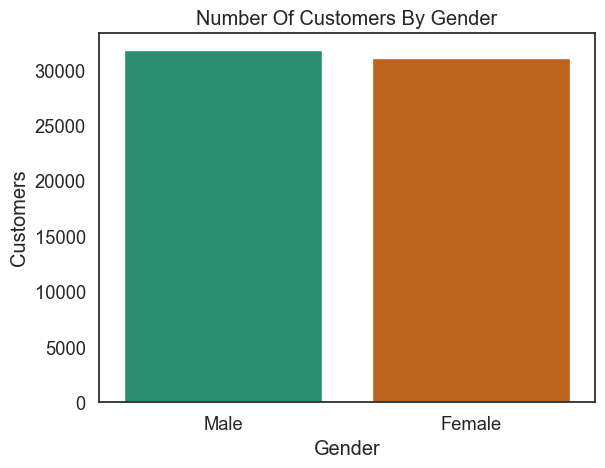

In [854]:
sns.barplot(data=customer_gender,x='Gender',y='CustomerKey')
plt.title("Number Of Customers By Gender")
plt.xlabel('Gender')
plt.ylabel('Customers')

In [855]:
df['Country'].value_counts()

United States     33767
United Kingdom     8140
Germany            5956
Canada             5415
Australia          2941
Italy              2655
Netherlands        2250
France             1730
Name: Country, dtype: int64

In [856]:
df['Country'].unique()

array(['Canada', 'United States', 'United Kingdom', 'Netherlands',
       'Italy', 'France', 'Germany', 'Australia'], dtype=object)

In [857]:
df['ProductKey'].nunique()

2492

In [858]:
number_product_category=df.groupby('Category')['ProductKey'].count().sort_values(ascending=False).reset_index()

Text(0, 0.5, 'Customers')

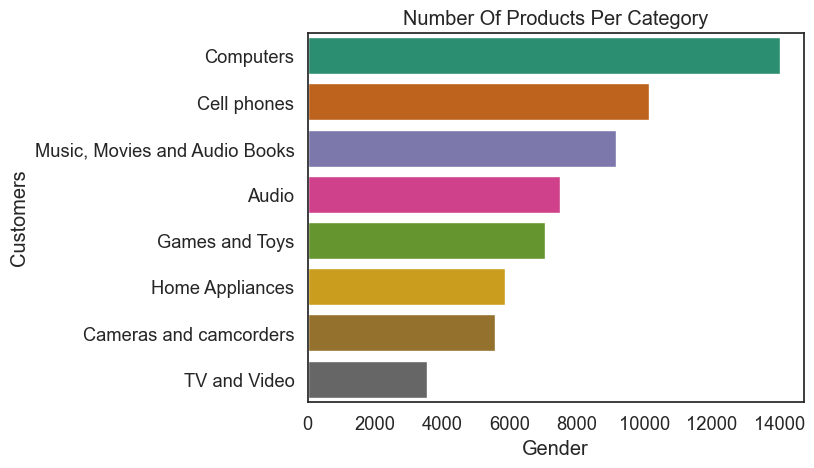

In [859]:
sns.barplot(data=number_product_category,x='ProductKey',y='Category')
plt.title("Number Of Products Per Category")
plt.xlabel('Gender')
plt.ylabel('Customers')

In [860]:
df['Unit Price USD'].mean()

280.5657501511439

In [861]:
df['Unit Price USD'].max()

3199.99

In [862]:
df['Unit Price USD'].min()

0.95

In [863]:
products['Unit Cost USD'].mean()

147.65556217719507

In [864]:
df.groupby('Category')['Unit Price USD'].sum().sort_values(ascending=False)

Category
Computers                        6083022.33
Home Appliances                  3392422.28
Cameras and camcorders           2064164.51
Cell phones                      1993941.86
TV and Video                     1872601.34
Audio                            1011115.13
Music, Movies and Audio Books     988825.13
Games and Toys                    228587.08
Name: Unit Price USD, dtype: float64

In [865]:
df.groupby('Category')['Unit Cost USD'].sum().sort_values(ascending=False)

Category
Computers                        2534275.71
Home Appliances                  1414382.41
Cell phones                       865848.76
Cameras and camcorders            821087.02
TV and Video                      754477.96
Audio                             427549.62
Music, Movies and Audio Books     385800.36
Games and Toys                    103324.54
Name: Unit Cost USD, dtype: float64

In [866]:
df['Order Number'].count()

62854

In [867]:
df['Quantity'].max()

10

### Delivery analysis

Delivery performance is analyzed only for transactions where a Delivery Date is available. Missing Delivery Date values are retained in the main sales dataset.

In [868]:
delivery_analysis = df.dropna(subset=['DeliveryDays']).copy()
delivery_analysis['DeliveryDays'].describe()

count    13163.000000
mean         4.529059
std          2.121224
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         17.000000
Name: DeliveryDays, dtype: float64

In [869]:
df['Year'].value_counts()

2019    21599
2018    14188
2020    11026
2017     7935
2016     6894
2021     1212
Name: Year, dtype: int64

In [870]:
df['Month'].value_counts()

12    8653
2     8454
1     7677
5     5337
10    5132
11    5111
9     4971
6     4895
8     4783
7     4441
3     2760
4      640
Name: Month, dtype: int64

In [871]:
df['Weekday'].value_counts()

Saturday     14917
Thursday     12150
Wednesday    11090
Tuesday       8608
Friday        8443
Monday        6530
Sunday        1116
Name: Weekday, dtype: int64

In [872]:
df['Quantity'].sum()

197671

In [873]:
df['Revenue'].sum()

55720996.66

In [874]:
df['Profit'].sum()

32642181.82

In [875]:
df['Revenue'].mean()

886.5147271454481

In [876]:
df['Profit'].mean()

519.3334047156903

In [877]:
df.groupby('Category')['Revenue']\
    .sum()\
    .sort_values(ascending=False)


Category
Computers                        19298921.06
Home Appliances                  10794148.75
Cameras and camcorders            6507103.03
Cell phones                       6179175.20
TV and Video                      5918016.91
Audio                             3168525.78
Music, Movies and Audio Books     3130276.50
Games and Toys                     724829.43
Name: Revenue, dtype: float64

In [878]:
df.groupby('Category')['Profit']\
    .sum()\
    .sort_values(ascending=False)

Category
Computers                        11276136.98
Home Appliances                   6295627.06
Cameras and camcorders            3911190.08
TV and Video                      3530366.55
Cell phones                       3496123.70
Music, Movies and Audio Books     1908876.39
Audio                             1827192.29
Games and Toys                     396668.77
Name: Profit, dtype: float64

In [879]:
df.groupby('Product Name')['Revenue'].sum().sort_values(
    ascending=False
).head(5)

Product Name
WWI Desktop PC2.33 X2330 Black                 505450.0
Adventure Works Desktop PC2.33 XD233 Silver    466089.0
Adventure Works Desktop PC2.33 XD233 Brown     464151.0
Adventure Works Desktop PC2.33 XD233 Black     447678.0
Adventure Works Desktop PC2.33 XD233 White     437019.0
Name: Revenue, dtype: float64

In [880]:
product_profit = (
    df
    .groupby('Product Name')
    .agg(
        Sales=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
    .sort_values('Profit', ascending=False)
)

product_profit.head(5)

,Product Name,Sales,Profit,Quantity
2381,WWI Desktop PC2.33 X2330 Black,505450.0,337986.00,550
246,Adventure Works Desktop PC2.33 XD233 Silver,466089.0,311663.95,481
245,Adventure Works Desktop PC2.33 XD233 Brown,464151.0,310368.05,479
244,Adventure Works Desktop PC2.33 XD233 Black,447678.0,299352.90,462
247,Adventure Works Desktop PC2.33 XD233 White,437019.0,292225.45,451


In [881]:
df.groupby('Brand')['Revenue']\
    .sum()\
    .sort_values(ascending=False)

Brand
Adventure Works         11841583.54
Contoso                 10789905.51
Wide World Importers     9170681.03
Fabrikam                 6798033.52
The Phone Company        5382412.00
Proseware                3212129.02
Litware                  2656302.78
Southridge Video         2578275.95
A. Datum                 1483072.80
Northwind Traders        1125869.56
Tailspin Toys             682730.95
Name: Revenue, dtype: float64

In [882]:
df.groupby('Brand')['Profit']\
    .sum()\
    .sort_values(ascending=False)

Brand
Adventure Works         6932855.64
Contoso                 6319901.15
Wide World Importers    5365900.18
Fabrikam                4054994.81
The Phone Company       3055394.87
Proseware               1935042.50
Litware                 1551628.07
Southridge Video        1522704.00
A. Datum                 881406.01
Northwind Traders        649305.29
Tailspin Toys            373049.30
Name: Profit, dtype: float64

In [883]:
year_Revenue=df.groupby('Year')['Revenue'].sum().reset_index().sort_values(by='Revenue',ascending=False)

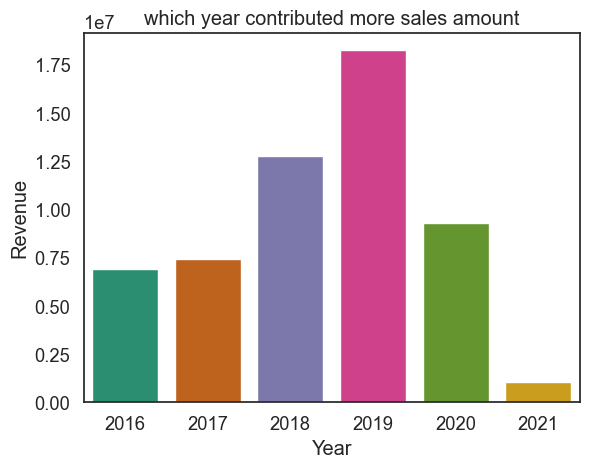

In [884]:
sns.barplot(data=year_Revenue,x='Year',y='Revenue')
plt.title("which year contributed more sales amount")
plt.xlabel("Year")
plt.ylabel('Revenue')

plt.savefig(
    CHART_DIR / "annual_sales.png",
    dpi=160,
    bbox_inches='tight'
)
plt.show()

In [885]:
df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)

Month
2     7829727.26
12    7496280.87
1     6745906.14
5     4757097.85
11    4755560.88
9     4363459.63
10    4311409.46
6     4291112.54
8     4085169.32
7     3852415.81
3     2625522.85
4      607334.05
Name: Revenue, dtype: float64

In [886]:
df['Age'].mean()

49.97379641709358

In [887]:
df['Age'].describe()

count    62854.000000
mean        49.973796
std         19.449779
min         14.000000
25%         33.000000
50%         50.000000
75%         67.000000
max         86.000000
Name: Age, dtype: float64

In [888]:
df.groupby('AgeGroup')['Order Number'].count()

AgeGroup
Under 18      980
18-30       12348
31-45       13922
46-60       13974
60+         21630
Name: Order Number, dtype: int64

In [889]:
df['StoreCountry'].value_counts()

United States     26555
Online            13163
United Kingdom     6643
Germany            4662
Canada             4206
Australia          2248
Italy              2173
Netherlands        1817
France             1387
Name: StoreCountry, dtype: int64

In [890]:
df['StoreState'].value_counts()

Online                          13163
Northwest Territories            1577
Kansas                           1519
Nevada                           1518
Nebraska                         1498
South Carolina                   1485
Oregon                           1472
Connecticut                      1471
New Mexico                       1442
Arkansas                         1436
West Virginia                    1395
Newfoundland and Labrador        1360
Maine                            1356
Washington DC                    1353
Hawaii                           1348
Alaska                           1340
Wyoming                          1295
Idaho                            1289
New Hampshire                    1287
Montana                          1284
Nunavut                          1269
Blaenau Gwent                    1054
Dungannon and South Tyrone       1050
Armagh                           1049
Iowa                             1041
Belfast                          1034
North Down  

In [891]:
df['Square Meters'].describe()

count    49691.000000
mean      1594.634944
std        461.760104
min        245.000000
25%       1260.000000
50%       1715.000000
75%       2000.000000
max       2105.000000
Name: Square Meters, dtype: float64

In [892]:
df['OpenYear'].value_counts().sort_index()

2005     2572
2007     1681
2008     6265
2009     3715
2010    21586
2012    10162
2013     2126
2014     3704
2015     8538
2018     2210
2019      295
Name: OpenYear, dtype: int64

In [893]:
store_sales = (
    df
    .groupby('StoreKey')
    .agg(
        Sales=('Revenue', 'sum'),
        Quantity=('Quantity', 'sum'),
        SquareMeters=('Square Meters', 'first')
    )
    .reset_index()
)

store_sales.head()

,StoreKey,Sales,Quantity,SquareMeters
0,0,11403548.65,41305,NaN
1,1,243029.93,871,595.0
2,2,15175.99,61,665.0
3,4,442475.02,1286,2000.0
4,5,859678.19,2944,2000.0


#### KPIs

In [894]:
order_value = df.groupby("Order Number")["Revenue"].sum()
kpis = pd.Series({
    "Revenue": f"${df['Revenue'].sum():,.0f}",
    "Profit": f"${df['Profit'].sum():,.0f}",
    "Profit margin": f"{df['Profit'].sum() / df['Revenue'].sum():.1%}",
    "Orders": f"{df['Order Number'].nunique():,}",
    "Line items": f"{len(df):,}",
    "Units sold": f"{df['Quantity'].sum():,}",
    "Average order value": f"${order_value.mean():,.0f}",
    "Median order value": f"${order_value.median():,.0f}",
    "Customers who purchased": f"{df['CustomerKey'].nunique():,}",
    "Period": f"{df['Order Date'].min():%d %b %Y} to {df['Order Date'].max():%d %b %Y}",
}, name="KPI")
kpis.to_frame()

,KPI
Revenue,"$55,720,997"
Profit,"$32,642,182"
Profit margin,58.6%
Orders,"26,313"
Line items,"62,854"
Units sold,"197,671"
Average order value,"$2,118"
Median order value,"$1,146"
Customers who purchased,"11,878"
Period,01 Jan 2016 to 20 Feb 2021


## 9.Questions 

### Q1. How did revenue and profit grow over time?

In [895]:
yearly = (
    df
    .groupby('Year')
    .agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Orders=('Order Number', 'nunique')
    )
)
yearly['Margin%']=yearly['Profit']/yearly['Revenue']*100
yearly['Revenue yoy%']=yearly['Revenue'].pct_change()*100
yearly.round(1)

,Revenue,Profit,Orders,Margin%,Revenue yoy%
Year,,,,,
2016,6924742.9,4093481.0,2862,59.1,NaN
2017,7418561.3,4335547.7,3276,58.4,7.1
2018,12788960.7,7464961.1,5965,58.4,72.4
2019,18254811.2,10692268.2,9077,58.6,42.7
2020,9294632.1,5447460.2,4635,58.6,-49.1
2021,1039288.5,608463.7,498,58.5,-88.8


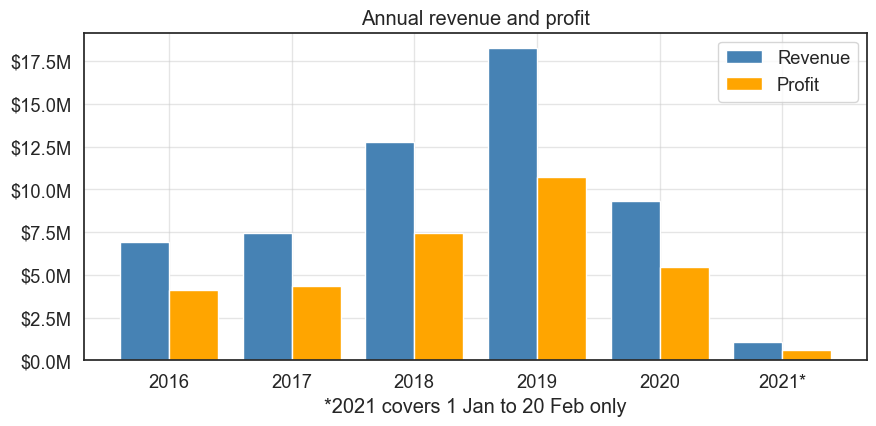

In [896]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(yearly))
ax.bar(x - 0.2, yearly["Revenue"], 0.4, label="Revenue", color="steelblue")
ax.bar(x + 0.2, yearly["Profit"], 0.4, label="Profit", color="orange")
ax.set_xticks(x)
ax.set_xticklabels([str(y) if y != 2021 else "2021*" for y in yearly.index])
ax.yaxis.set_major_formatter(usd_m)
ax.set_title("Annual revenue and profit")
ax.set_xlabel("*2021 covers 1 Jan to 20 Feb only")
ax.grid(True, linestyle='-', alpha=0.5)
ax.legend()

save_fig("01_revenue_profit")
plt.show()

**Insight:** revenue grew from $6.9M in 2016 to a peak of $18.3M in 2019 (+72% in 2018, +43% in 2019), then fell 49% to $9.3M in 2020. Margin stayed at about 58% to 59% every year, so the swings come from volume, not pricing. 2021 holds only seven weeks of data and should not be compared with full years.

### Q2. What seasonal and weekday patterns exist?

In [897]:
monthly = df.groupby("YearMonth")["Revenue"].sum()

complete_years = df[df["Year"] <= 2020]
season = complete_years.groupby("Month")["Revenue"].sum()
season_index = season / season.mean()




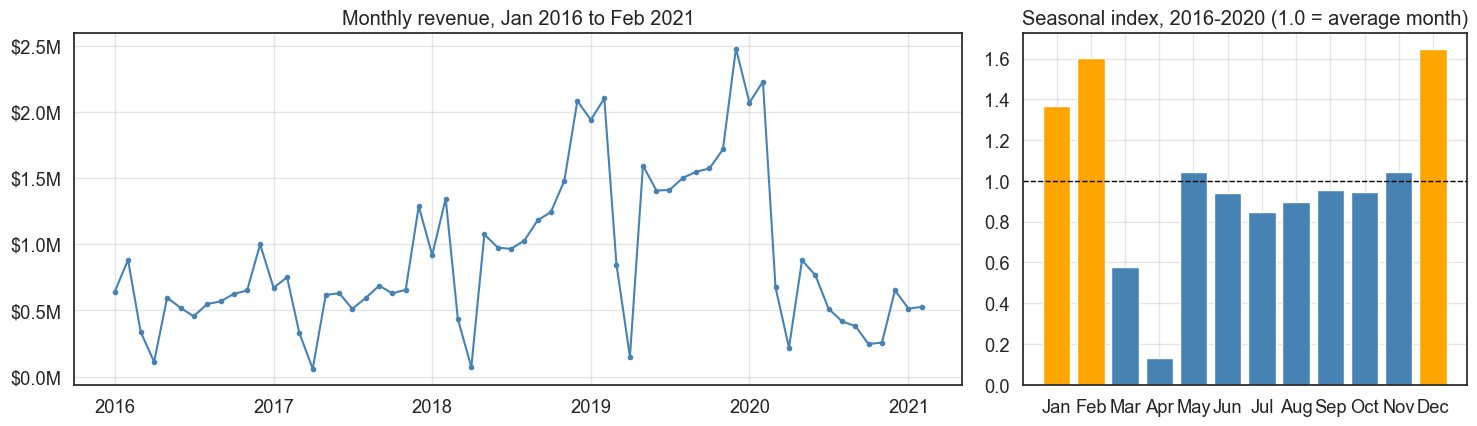

In [898]:

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(monthly.index.to_timestamp(), monthly.values, marker="o", markersize=3, color='steelblue')
axes[0].yaxis.set_major_formatter(usd_m)
axes[0].set_title("Monthly revenue, Jan 2016 to Feb 2021")
axes[0].grid(True, linestyle='-', alpha=0.5)

axes[1].bar([calendar.month_abbr[m] for m in season_index.index], season_index.values,
            color=['orange' if v > 1.3 else 'steelblue'  for v in season_index.values])
axes[1].axhline(1, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Seasonal index, 2016-2020 (1.0 = average month)")
axes[1].grid(True, linestyle='-', alpha=0.5)
save_fig("02_seasonality")
plt.show()

In [899]:
season_index.round(2).rename(index=lambda m: calendar.month_abbr[m]).to_frame("Seasonal index")

,Seasonal index
Month,
Jan,1.37
Feb,1.60
Mar,0.58
Apr,0.13
May,1.04
Jun,0.94
Jul,0.85
Aug,0.90
Sep,0.96


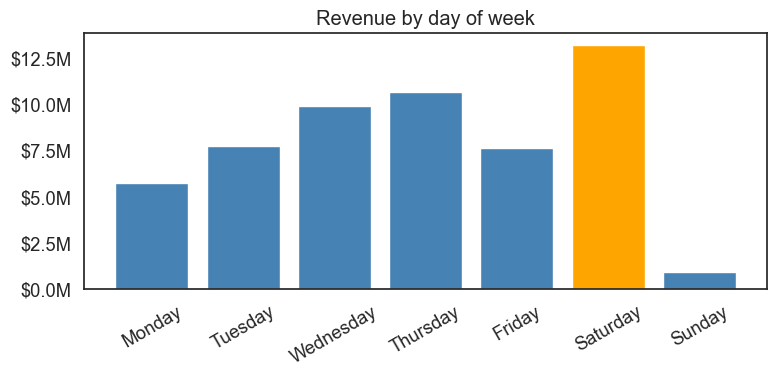

,Share of revenue %
Weekday,
Monday,10.3
Tuesday,13.8
Wednesday,17.8
Thursday,19.1
Friday,13.7
Saturday,23.7
Sunday,1.6


In [900]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = df.groupby("Weekday")["Revenue"].sum().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(weekday.index, weekday.values, color=['orange' if d == "Saturday" else 'steelblue' for d in weekday.index])
ax.yaxis.set_major_formatter(usd_m)
ax.set_title("Revenue by day of week")
plt.xticks(rotation=30)
save_fig("02_weekday_revenue")
plt.show()

(weekday / weekday.sum() * 100).round(1).to_frame("Share of revenue %")

**Insight:** across 2016 to 2020, December (1.64x an average month) and February (1.60x) are the peaks, and January is also strong (1.37x). April collapses to 0.13x of an average month, with March at 0.58x, and this dip repeats in **every** year, so it is a real pattern in the data, not a one-off. Saturday is the strongest day (23.7% of revenue) and Sunday is almost empty (1.6%).

### Q3. Which categories drive profit, and how do their margins compare?

In [901]:
category = df.groupby("Category").agg(Revenue=("Revenue", "sum"), Profit=("Profit", "sum"),
                                      Units=("Quantity", "sum"))
category["Margin %"] = category["Profit"] / category["Revenue"] * 100
category["Profit share %"] = category["Profit"] / category["Profit"].sum() * 100
category = category.sort_values("Profit", ascending=False)
category.round(1)

,Revenue,Profit,Units,Margin %,Profit share %
Category,,,,,
Computers,19298921.1,11276137.0,44140,58.4,34.5
Home Appliances,10794148.8,6295627.1,18394,58.3,19.3
Cameras and camcorders,6507103.0,3911190.1,17593,60.1,12.0
TV and Video,5918016.9,3530366.6,11222,59.7,10.8
Cell phones,6179175.2,3496123.7,31452,56.6,10.7
"Music, Movies and Audio Books",3130276.5,1908876.4,28796,61.0,5.8
Audio,3168525.8,1827192.3,23483,57.7,5.6
Games and Toys,724829.4,396668.8,22591,54.7,1.2


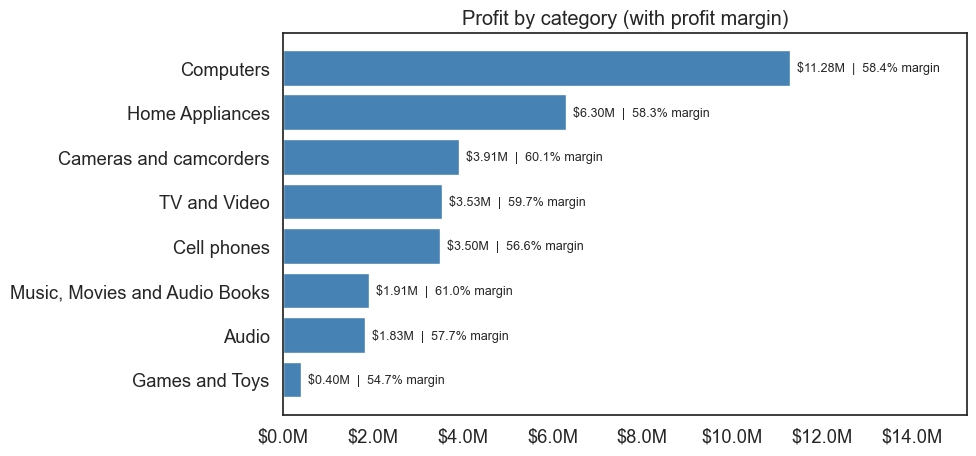

In [902]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(category.index[::-1], category["Profit"][::-1], color="steelblue")
for i, (profit, margin) in enumerate(zip(category["Profit"][::-1], category["Margin %"][::-1])):
    ax.text(profit, i, f"  ${profit / 1e6:.2f}M  |  {margin:.1f}% margin", va="center", fontsize=9)
ax.xaxis.set_major_formatter(usd_m)
ax.set_xlim(0, category["Profit"].max() * 1.35)
ax.set_title("Profit by category (with profit margin)")
save_fig("03_category_profit_margin")
plt.show()

### Q4. Which brands generate high sales but weaker margins?

In [903]:
brand_performance = (
    df
    .groupby('Brand')
    .agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
    )
)
brand_performance["Margin %"] = brand_performance["Profit"] / brand_performance["Revenue"] * 100
brand_performance = brand_performance.sort_values("Revenue", ascending=False)
brand_performance.round(1)

,Revenue,Profit,Margin %
Brand,,,
Adventure Works,11841583.5,6932855.6,58.5
Contoso,10789905.5,6319901.2,58.6
Wide World Importers,9170681.0,5365900.2,58.5
Fabrikam,6798033.5,4054994.8,59.6
The Phone Company,5382412.0,3055394.9,56.8
Proseware,3212129.0,1935042.5,60.2
Litware,2656302.8,1551628.1,58.4
Southridge Video,2578276.0,1522704.0,59.1
A. Datum,1483072.8,881406.0,59.4


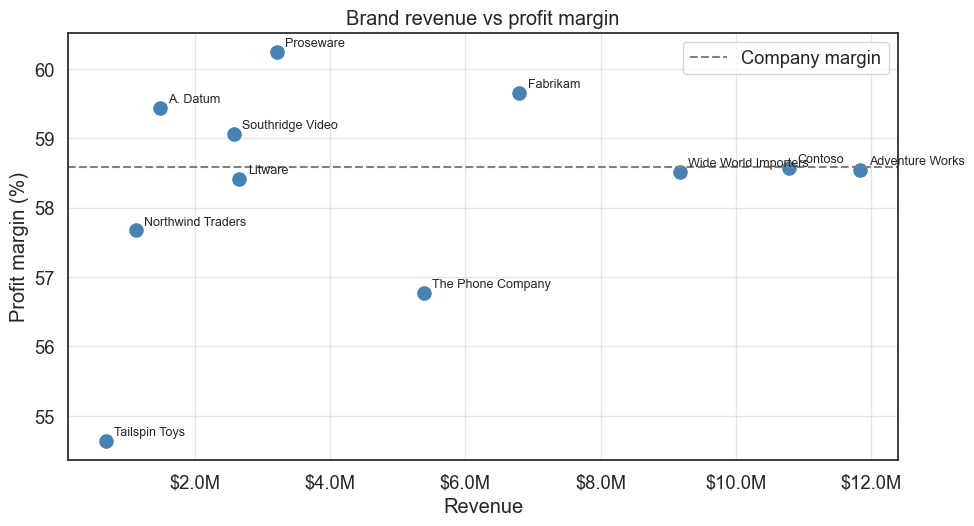

In [904]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(brand_performance["Revenue"], brand_performance["Margin %"], s=90, color='steelblue')
for name, row in brand_performance.iterrows():
    ax.annotate(name, (row["Revenue"], row["Margin %"]), xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.axhline(df["Profit"].sum() / df["Revenue"].sum() * 100, color='GREY', linestyle="--", label="Company margin")
ax.xaxis.set_major_formatter(usd_m)
ax.set_xlabel("Revenue")
ax.set_ylabel("Profit margin (%)")
ax.set_title("Brand revenue vs profit margin")
ax.legend()
ax.grid(True, linestyle='-', alpha=0.5)
save_fig("04_brand_revenue_profit_margin")
plt.show()


**Insight:** Adventure Works is the largest brand ($11.85M revenue, 58.5% margin). **The Phone Company** is the clearest "high sales, weaker margin" brand: fifth by revenue ($5.39M) with a 56.8% margin, the lowest of the top five (the others earn 58.5% to 59.7%). Tailspin Toys has the lowest margin overall (54.6%) on very small sales ($0.68M).

### Q5. Is product price associated with quantity sold?

In [905]:
price_quantity = (
    df
    .groupby('Product Name')
    .agg(
        UnitPrice=('Unit Price USD', 'first'),
        QuantitySold=('Quantity', 'sum')
    )
)

In [906]:
price_quantity[['UnitPrice', 'QuantitySold']].corr()

,UnitPrice,QuantitySold
UnitPrice,1.000000,-0.129158
QuantitySold,-0.129158,1.000000


In [907]:
pearson = price_quantity["UnitPrice"].corr(price_quantity["QuantitySold"])
spearman = price_quantity["UnitPrice"].corr(price_quantity["QuantitySold"], method="spearman")
print(f"Products analysed: {len(price_quantity):,}")
print(f"Pearson r = {pearson:.3f}")
print(f"Spearman r = {spearman:.3f}")

Products analysed: 2,492
Pearson r = -0.129
Spearman r = -0.148


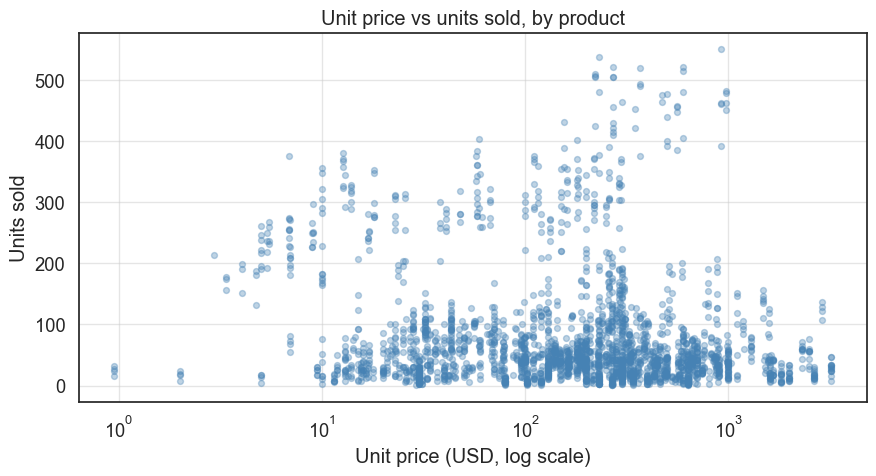

In [908]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(price_quantity["UnitPrice"], price_quantity["QuantitySold"], alpha=0.35, s=18, color='steelblue')
ax.set_xscale("log")
ax.set_xlabel("Unit price (USD, log scale)")
ax.set_ylabel("Units sold")
ax.set_title("Unit price vs units sold, by product")
ax.grid(True, linestyle='-', alpha=0.5)
save_fig("05_price_vs_quantity")
plt.show()

**Insight:** the relationship is weak: Pearson r = -0.13 and Spearman rho = -0.15. Expensive products tend to sell slightly fewer units, but price explains very little of the variation in volume, so pricing alone is not a reliable lever for predicting demand.

### Q6. Which products generate the highest and lowest profit per unit?

In [933]:
product_unit = (
    df.groupby(["ProductKey", "Product Name"])
    .agg(Units=("Quantity", "sum"), Revenue=("Revenue", "sum"), Profit=("Profit", "sum"))
    .reset_index()
)
product_unit["Profit per unit"] = product_unit["Profit"] / product_unit["Units"]
product_unit["Margin %"] = product_unit["Profit"] / product_unit["Revenue"] * 100

top_value = round(product_unit["Profit per unit"].max(), 2)
n_tied = int((product_unit["Profit per unit"].round(2) == top_value).sum())
print(f"{n_tied} products tie for the highest profit per unit (${top_value:,.2f}).")


14 products tie for the highest profit per unit ($2,139.77).


In [931]:
top10 = product_unit.nlargest(10, "Profit per unit")
bottom10 = product_unit.nsmallest(10, "Profit per unit")

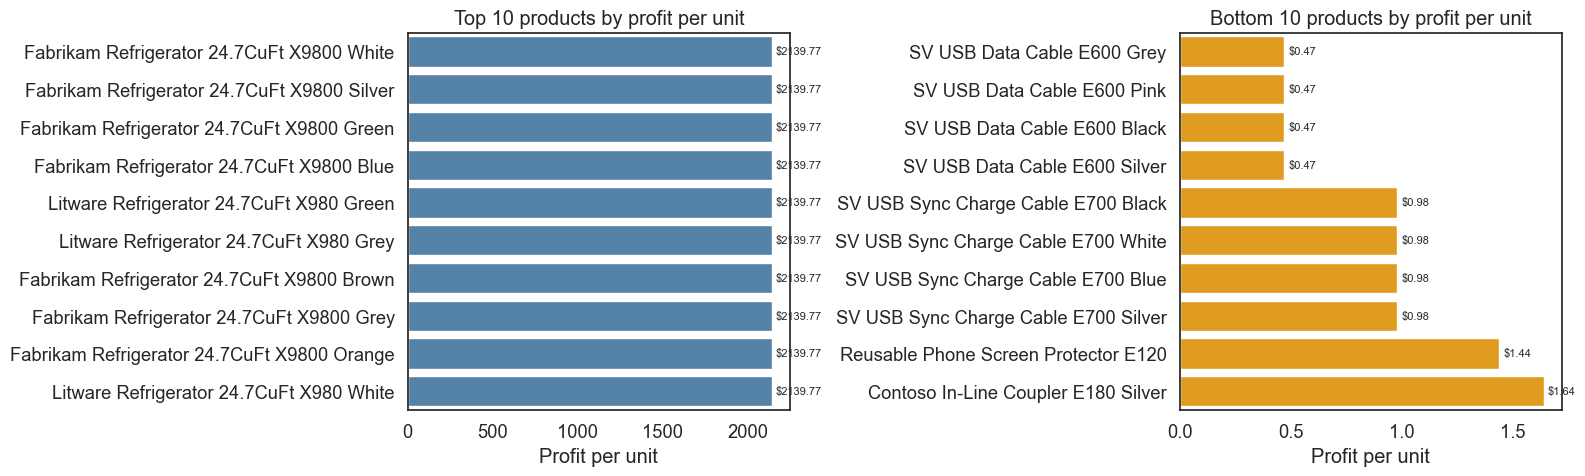

In [910]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=top10, x="Profit per unit", y="Product Name", color='steelblue', ax=axes[0])
axes[0].set_title("Top 10 products by profit per unit")
sns.barplot(data=bottom10, x="Profit per unit", y="Product Name", color='orange', ax=axes[1])
axes[1].set_title("Bottom 10 products by profit per unit")
for ax in axes:
    ax.set_ylabel("")
    ax.bar_label(ax.containers[0], fmt="$%.2f", padding=3, fontsize=8)
save_fig("06_profit_per_unit")
plt.show()

In [911]:
product_unit.sort_values("Profit per unit").head(5)[["Product Name", "Units", "Profit per unit", "Margin %"]].round(2)

,Product Name,Units,Profit per unit,Margin %
920,SV USB Data Cable E600 Grey,23,0.47,49.47
919,SV USB Data Cable E600 Silver,16,0.47,49.47
918,SV USB Data Cable E600 Black,32,0.47,49.47
917,SV USB Data Cable E600 Pink,27,0.47,49.47
923,SV USB Sync Charge Cable E700 White,24,0.98,49.25


**Insight:** 24.7 cu ft refrigerator models from Fabrikam and Litware top the list at $2,139.77 profit per unit; 14 colour variants tie because they share the same price and cost. At the other end are low-priced accessories: SV USB Data Cable E600 variants earn $0.47 per unit and SV USB Sync Charge Cable E700 variants $0.98. Profit per unit mostly mirrors price, since margins sit in a narrow band of about 49% to 67% for every product, so total profit depends on how many units each product sells.

### Q7. How concentrated is revenue among customers?

In [912]:
customer_revenue = df.groupby("CustomerKey")["Revenue"].sum().sort_values(ascending=False)
total = customer_revenue.sum()
n = len(customer_revenue)

top10_share = customer_revenue.head(10).sum() / total * 100
top10pct_share = customer_revenue.head(int(n * 0.10)).sum() / total * 100
top20pct_share = customer_revenue.head(int(n * 0.20)).sum() / total * 100

orders_per_customer = df.groupby("CustomerKey")["Order Number"].nunique()
repeat_rate = (orders_per_customer > 1).mean() * 100

print(f"Customers who purchased: {n:,} of {len(customers):,}")
print(f"Top 10 customers: {top10_share:.2f}% of revenue (largest single customer ${customer_revenue.iloc[0]:,.0f})")
print(f"Top 10% of customers: {top10pct_share:.1f}% of revenue")
print(f"Top 20% of customers: {top20pct_share:.1f}% of revenue")
print(f"Repeat buyers (2+ orders): {repeat_rate:.1f}%")

cum_share = customer_revenue.cumsum() / total * 100
cust_pct = np.arange(1, n + 1) / n * 100


Customers who purchased: 11,878 of 15,256
Top 10 customers: 0.76% of revenue (largest single customer $61,872)
Top 10% of customers: 36.0% of revenue
Top 20% of customers: 55.3% of revenue
Repeat buyers (2+ orders): 61.2%


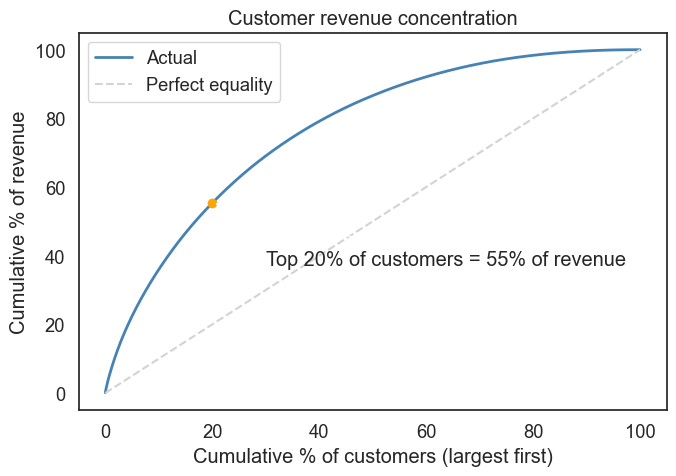

In [913]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cust_pct, cum_share.values, color='steelblue', linewidth=2, label="Actual")
ax.plot([0, 100], [0, 100], color='lightgray', linestyle="--", label="Perfect equality")
ax.scatter([20], [top20pct_share], color='orange', zorder=3)
ax.annotate(f"Top 20% of customers = {top20pct_share:.0f}% of revenue", (20, top20pct_share),
            xytext=(30, top20pct_share - 18), arrowprops={"arrowstyle": "->"})
ax.set_xlabel("Cumulative % of customers (largest first)")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Customer revenue concentration")
ax.legend()
save_fig("07_customer_concentration")
plt.show()

**Insight:** no single customer matters much: the 10 biggest customers account for only 0.76% of revenue, and the largest spent about $61.9K. Concentration is moderate rather than extreme: the top 10% of customers bring 36.0% of revenue and the top 20% bring 55.3%. Customer loyalty is healthy, with 61.2% of buyers placing more than one order, so retention programs have a large base to work with.

### Q8. Which customer segment matter most?

In [914]:
def segment(column, observed=True):
    out = df.groupby(column, observed=observed).agg(Revenue=("Revenue", "sum"), Profit=("Profit", "sum"))
    out["Revenue share %"] = out["Revenue"] / out["Revenue"].sum() * 100
    return out

gender, age, country = segment("Gender"), segment("AgeGroup"), segment("Country").sort_values("Revenue", ascending=False)


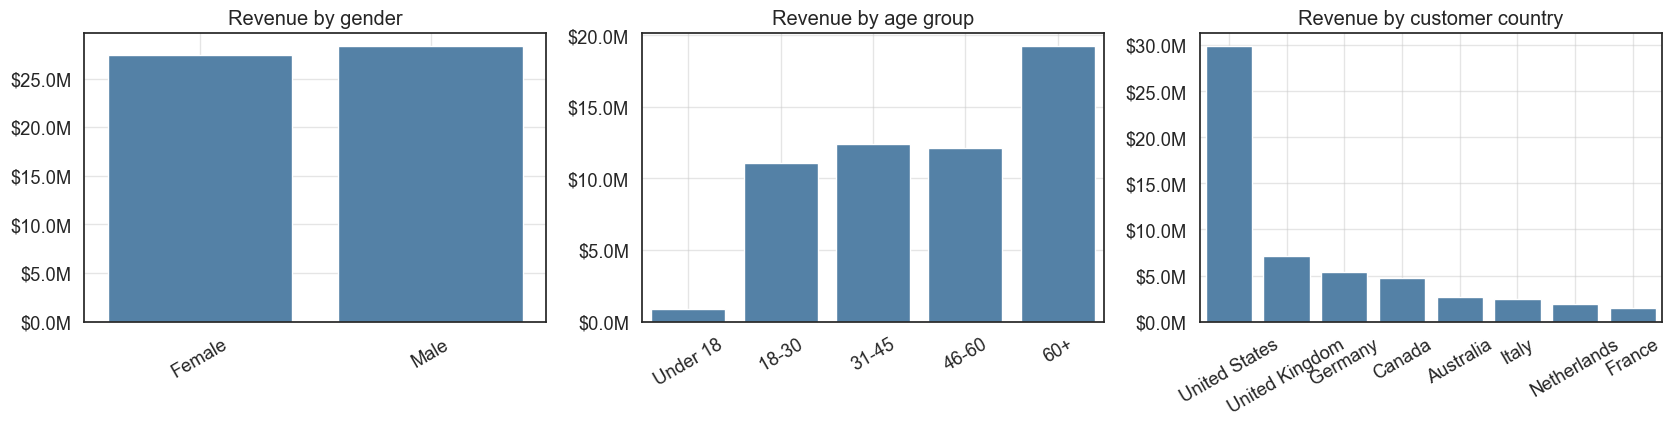

In [915]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, table, title in zip(axes, [gender, age, country], ["Gender", "Age group", "Customer country"]):
    sns.barplot(x=table.index.astype(str), y=table["Revenue"], color='steelblue', ax=ax)
    ax.yaxis.set_major_formatter(usd_m)
    ax.set_title(f"Revenue by {title.lower()}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, linestyle='-', alpha=0.5)
save_fig("08_customer_segments")
plt.show()



In [916]:
pd.concat({"Gender": gender, "Age group": age, "Country": country})[["Revenue", "Revenue share %"]].round(1)

Revenue  Revenue share %
Gender    Female          27407850.4             49.2
          Male            28313146.3             50.8
Age group Under 18          859376.3              1.5
          18-30           11090316.8             19.9
          31-45           12385459.2             22.2
          46-60           12158211.1             21.8
          60+             19227633.2             34.5
Country   United States   29871631.2             53.6
          United Kingdom   7084088.1             12.7
          Germany          5414149.8              9.7
          Canada           4724334.6              8.5
          Australia        2708137.6              4.9
          Italy            2441162.8              4.4
          Netherlands      1962154.3              3.5
          France           1515338.2              2.7

**Insight:** gender is almost balanced (male 50.8%, female 49.2%), so it is not a useful targeting lever. Age is more telling: customers aged 60+ generate $19.2M, 34.5% of revenue, more than any other group, while under-18s add under 2%. Geography is the strongest divider: US customers produce $29.9M, 53.6% of revenue, followed by the United Kingdom ($7.1M) and Germany ($5.4M). Age is approximated as order year minus birth year.

### Q9. How do online and physical-store revenue compare?

In [917]:
channel = df.groupby("Channel").agg(Revenue=("Revenue", "sum"), Profit=("Profit", "sum"),
                                    Orders=("Order Number", "nunique"))
channel["Margin %"] = channel["Profit"] / channel["Revenue"] * 100
channel["Revenue share %"] = channel["Revenue"] / channel["Revenue"].sum() * 100



In [918]:
channel_year = df.pivot_table(index="Year", columns="Channel", values="Revenue", aggfunc="sum")
online_share = channel_year["Online"] / channel_year.sum(axis=1) * 100



In [919]:
store_revenue = df[df["StoreKey"] != 0].groupby("StoreKey")["Revenue"].sum()
print(f"Online revenue: ${channel.loc['Online', 'Revenue']:,.0f}")
print(f"Best physical store (StoreKey {store_revenue.idxmax()}): ${store_revenue.max():,.0f}")
print(f"Online = {channel.loc['Online', 'Revenue'] / store_revenue.max():.1f}x the best physical store")
print("\nOnline share of revenue by year (%):")
print(online_share.round(1).to_string())



Online revenue: $11,403,549
Best physical store (StoreKey 55): $1,417,885
Online = 8.0x the best physical store

Online share of revenue by year (%):
Year
2016    16.9
2017    18.7
2018    20.2
2019    21.4
2020    22.3
2021    27.5


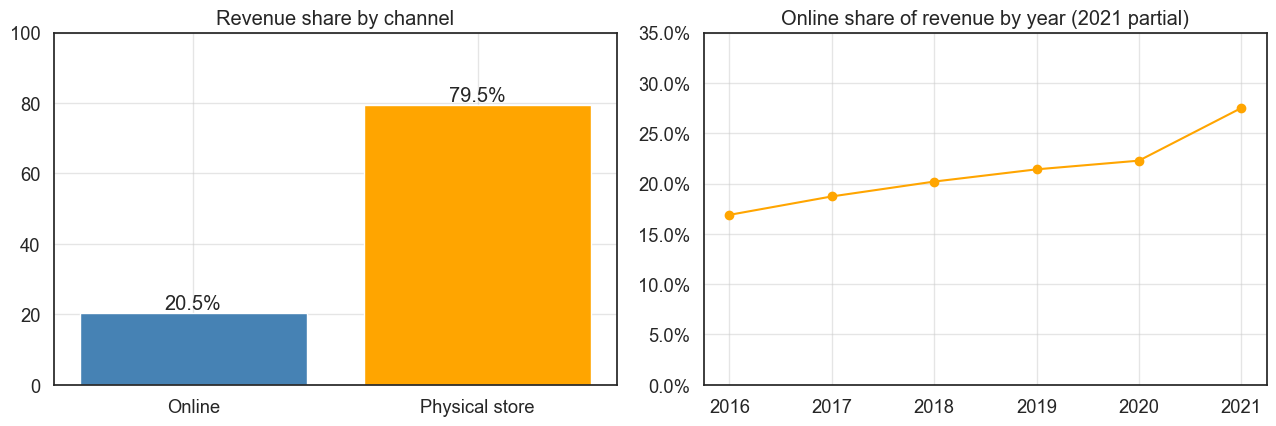

,Revenue,Profit,Orders,Margin %,Revenue share %
Channel,,,,,
Online,11403548.6,6672312.3,5579,58.5,20.5
Physical store,44317448.0,25969869.5,20734,58.6,79.5


In [920]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(channel.index, channel["Revenue share %"], color=['steelblue', 'orange'])
for i, v in enumerate(channel["Revenue share %"]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")
axes[0].set_ylim(0, 100)
axes[0].set_title("Revenue share by channel")
axes[0].grid(True, linestyle='-', alpha=0.5)
axes[1].plot(online_share.index, online_share.values, marker="o", color='orange')
axes[1].set_ylim(0, 35)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(True, linestyle='-', alpha=0.5)
axes[1].set_title("Online share of revenue by year (2021 partial)")
save_fig("09_online_vs_physical")
plt.show()

channel.round(1)

**Insight:** physical stores bring 79.5% of revenue ($44.35M across 57 stores with sales) and online brings 20.5% ($11.40M). Margins are the same (58.5% online, 58.6% stores). Online is one channel, yet earns about 8x the best single store ($1.42M), and its share has climbed steadily from 16.8% in 2016 to 22.3% in 2020.

### Q10. Is store size related to store revenue?

Store 0 (online) is excluded because it has no floor area. Store tenure is checked as a possible confounder, since older stores have had more time to sell.

In [921]:
data_end = df["Order Date"].max()
store_perf = (
    df[df["StoreKey"] != 0].groupby("StoreKey").agg(Revenue=("Revenue", "sum"), Profit=("Profit", "sum"))
    .join(stores.set_index("StoreKey")[["Country", "State", "Square Meters", "Open Date"]])
)


In [922]:
store_perf["Revenue per sqm"] = store_perf["Revenue"] / store_perf["Square Meters"]
store_perf["Years open"] = (data_end - store_perf["Open Date"]).dt.days / 365.25



In [923]:
size_pearson = store_perf["Square Meters"].corr(store_perf["Revenue"])
size_spearman = store_perf["Square Meters"].corr(store_perf["Revenue"], method="spearman")
tenure_corr = store_perf["Years open"].corr(store_perf["Revenue"])
print(f"Physical stores with sales: {len(store_perf)} of {(stores['StoreKey'] != 0).sum()}")
print(f"Store size vs revenue: Pearson r = {size_pearson:.3f}, Spearman rho = {size_spearman:.3f}")
print(f"Years open vs revenue: r = {tenure_corr:.3f}")



Physical stores with sales: 57 of 66
Store size vs revenue: Pearson r = 0.602, Spearman rho = 0.534
Years open vs revenue: r = 0.049


In [924]:
no_sales = stores[(stores["StoreKey"] != 0) & ~stores["StoreKey"].isin(store_perf.index)]
print("\nPhysical stores with no recorded sales:")
print(no_sales[["StoreKey", "Country", "State", "Square Meters", "Open Date"]].to_string(index=False))




Physical stores with no recorded sales:
 StoreKey       Country                  State  Square Meters  Open Date
        3     Australia        South Australia         2000.0 2012-01-07
        7        Canada          New Brunswick         1105.0 2007-05-07
       11        Canada                  Yukon         1210.0 2009-06-03
       25       Germany Mecklenburg-Vorpommern         1610.0 2010-01-01
       35   Netherlands                Zeeland         1225.0 2007-05-07
       46 United States               Delaware         1015.0 2012-08-08
       52 United States            Mississippi         2000.0 2009-06-03
       58 United States           North Dakota         1330.0 2007-07-08
       60 United States           Rhode Island         1260.0 2005-04-04


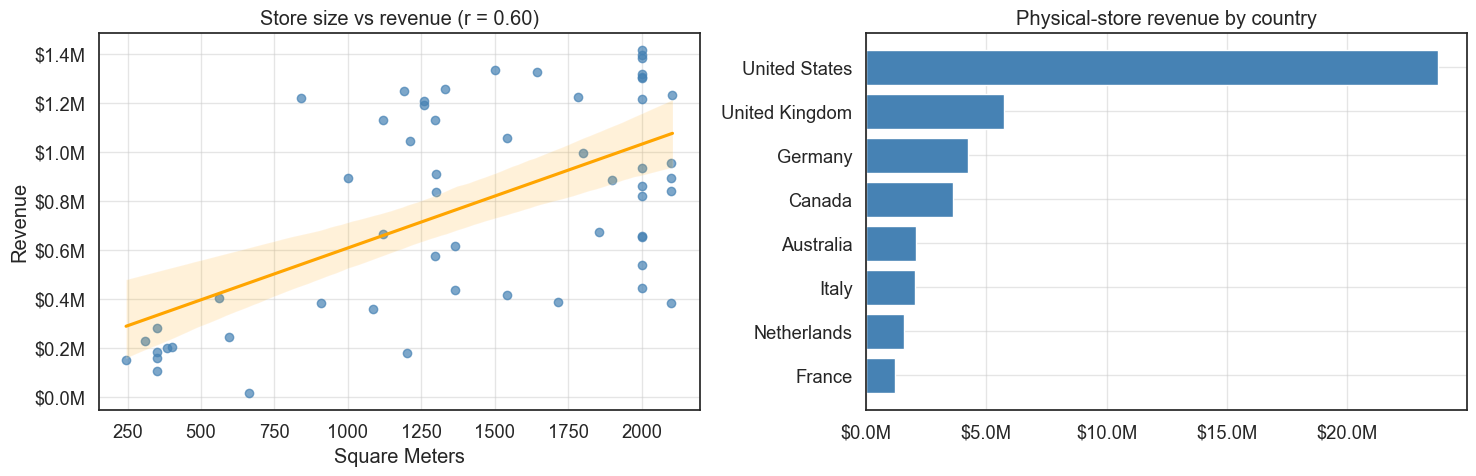

,Country,State,Square Meters,Revenue,Revenue per sqm
StoreKey,,,,,
55,United States,Nevada,2000.0,1417885.0,709.0
50,United States,Kansas,2000.0,1394738.0,697.0
54,United States,Nebraska,2000.0,1384396.0,692.0
13,France,Corse,245.0,150925.0,616.0
14,France,Franche-Comté,350.0,105714.0,302.0
2,Australia,Northern Territory,665.0,15176.0,23.0


In [925]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(data=store_perf, x="Square Meters", y="Revenue", color='steelblue', ax=axes[0],
            scatter_kws={"alpha": 0.7}, line_kws={"color": 'orange'})
axes[0].yaxis.set_major_formatter(usd_m)
axes[0].set_title(f"Store size vs revenue (r = {size_pearson:.2f})")
by_country = store_perf.groupby("Country")["Revenue"].sum().sort_values()
axes[0].grid(True, linestyle='-', alpha=0.5)
axes[1].barh(by_country.index, by_country.values, color='steelblue')
axes[1].xaxis.set_major_formatter(usd_m)
axes[1].set_title("Physical-store revenue by country")
axes[1].grid(True, linestyle='-', alpha=0.5)
save_fig("10_store_size_and_country")
plt.show()

store_perf.sort_values("Revenue", ascending=False)[["Country", "State", "Square Meters", "Revenue", "Revenue per sqm"]].round(0).iloc[[0, 1, 2, -3, -2, -1]]

**Insight:** among the 57 physical stores with sales, larger stores earn more revenue (Pearson r = 0.60, Spearman rho = 0.53), a moderate relationship. Store age is not the explanation (r = 0.05), so larger floor space appears to matter by itself, though it is still far from the whole story. Nine physical stores have no recorded sales (listed above) and deserve a data check or a closure review; the weakest store with sales is in Australia's Northern Territory at roughly $15K. The US generates the most physical-store revenue by a wide margin, which has 24 of the 66 stores.

### Q11. How fast is online delivery?

In [926]:
delivery = df[df["DeliveryDays"].notnull()]
print(f"Online line items with a delivery date: {len(delivery):,}")
print(delivery["DeliveryDays"].describe().round(1).to_string())


Online line items with a delivery date: 13,163
count    13163.0
mean         4.5
std          2.1
min          1.0
25%          3.0
50%          4.0
75%          6.0
max         17.0


In [927]:
delivery_by_year = delivery.groupby("Year")["DeliveryDays"].mean()
print("\nAverage delivery days by order year:")
print(delivery_by_year.round(1).to_string())


Average delivery days by order year:
Year
2016    7.3
2017    5.2
2018    4.3
2019    4.1
2020    4.0
2021    3.8


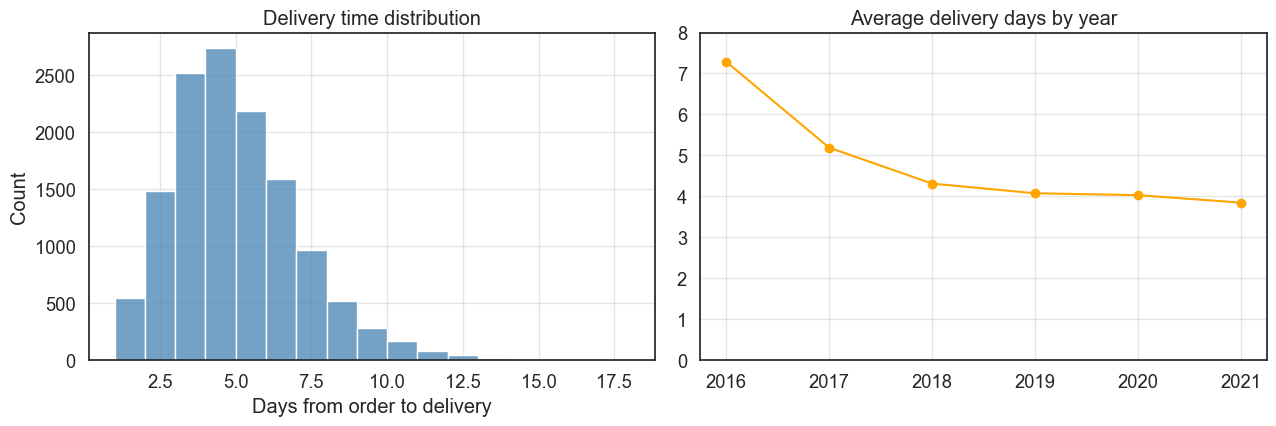

In [928]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(delivery["DeliveryDays"], bins=range(1, 19), color='steelblue', ax=axes[0])
axes[0].set_xlabel("Days from order to delivery")
axes[0].set_title("Delivery time distribution")
axes[0].grid(True, linestyle='-', alpha=0.5)
axes[1].plot(delivery_by_year.index, delivery_by_year.values, marker="o", color='orange')
axes[1].set_ylim(0, 8)
axes[1].set_title("Average delivery days by year")
axes[1].grid(True, linestyle='-', alpha=0.5)
save_fig("11_delivery_time")
plt.show()

**Insight:** online orders arrive in 4.5 days on average (median 4, 75% within 6, worst case 17). Delivery has improved sharply, from 7.3 days for 2016 orders to 4.0 days for 2020 orders, which fits the rise in online share. Only online orders carry a delivery date, so nothing can be said about in-store fulfillment.

### Q12. Which numeric variables are related?

`Unit Cost` and `Profit` are left out on purpose: profit is computed from revenue and cost, so their correlations are true by construction and would not be insights.

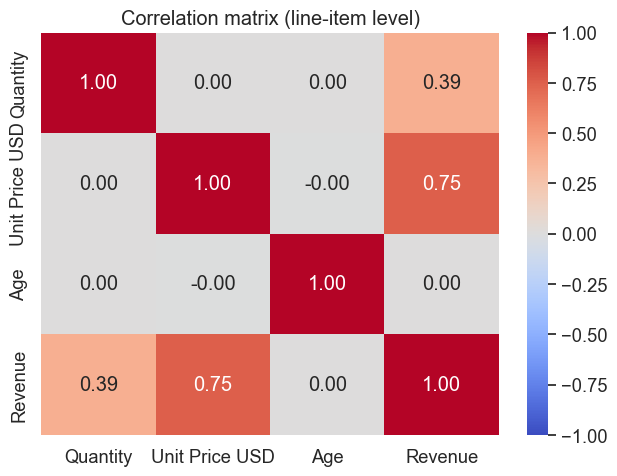

In [929]:
corr = df[["Quantity", "Unit Price USD", "Age", "Revenue"]].corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix (line-item level)")
save_fig("12_correlation_matrix")
plt.show()

**Insight:** revenue per line item is driven mainly by price (r = 0.75) and, less so, quantity (r = 0.39). Customer age has essentially no linear relationship with price, quantity or revenue, so age is useful for describing customers but not for predicting basket value.

## 10.Key Insights
1. **Computers and Home Appliances produce 53.8% of profit.** Computers alone are 34.5%.
2. **Volume, not margin, separates winners.** Category margins span only 54.7% to 61.0%.
3. **Growth peaked in 2019 ($18.3M) and halved in 2020.** The cause is outside this dataset and needs follow-up.
4. **Demand is strongly seasonal:** peaks in December and February, a trough in April in every year, a strong Saturday and a near-empty Sunday.
5. **Online is a growing, equally profitable channel** (16.8% to 22.3% share, 2016 to 2020).
6. **Revenue is spread across customers** (top 10 = 0.76%), but the top 20% bring 55% and 61% of buyers are repeat customers.
7. **Store size matters (r = 0.60); store age does not (r = 0.05).** Nine physical stores show no sales.


## 11.Recommendaation

1. **Plan around the calendar.** Build inventory, staffing and promotions ahead of the December to February peak, and test a targeted April campaign, since April is weak every year.
2. **Protect the profit engine.** Keep Computers and Home Appliances well stocked and priced, because they carry over half of profit.
3. **Review lower-margin lines.** Negotiate costs on The Phone Company and Cell phones (56.6% margin) and review Games and Toys and Tailspin Toys (lowest margins and small sales).
4. **Keep investing in online.** It matches store margins, grows its share every year and delivers faster than before.
5. **Investigate the nine stores with no sales** and the weakest store with sales, to confirm whether the data is missing or the stores are underperforming.
6. **Use the customer base.** Build retention offers for repeat buyers and the top 20% of customers, and design for the 60+ segment, the largest age group.
7. **Test Sunday trading.** Sunday carries 1.6% of revenue; find out whether stores close and what the opportunity is.

## 12.Conclusion

Revenue grew rapidly from 2016 to 2019 ($6.9M to $18.3M) before falling 49% in 2020, while margin stayed near 58–59%, so performance was driven by sales volume rather than pricing. Stores generate 79.5% of revenue, but online is growing steadily (16.8% to 22.3% share) at equal margin with faster delivery. Larger stores earn more (r = 0.60), and nine stores show no sales, which should be verified. Sales peak in December–February and drop sharply in April and on Sundays; both should be checked for data gaps before acting on them. The business should prioritise seasonal planning, protect its high-profit categories, and invest in online growth. Limitations: revenue is based on list prices, with no discount or return data.